# Statistical tests for Attack B

Cleaned version of the notebook. The repeated plotting and statistical-test code is grouped into helper functions, and the figures follow the same design as the cleaned Attack A notebook.


In [1]:
import colorsys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats
from scipy.stats import kruskal

try:
    import scikit_posthocs as sp
except ModuleNotFoundError:
    sp = None
    print("Optional dependency missing: install scikit-posthocs to run Dunn post-hoc tests.")


In [2]:
DATA_PATH = Path('Attack-B-Results.csv')

# Fallback for when the notebook is executed from a different working directory.
if not DATA_PATH.exists():
    DATA_PATH = Path('./data/Attack-B-Results.csv')

MODEL_ORDER = ['1V', '2V']
LOSS_NAMES = ['Clean', 'FGSM']

LOSS_COL_MAP = {
    'Clean': 'Clean_IM_Loss',
    'FGSM': 'FGSM_IM_Loss',
}

LABEL_LOSS_COL_MAP = {
    'Clean': 'Clean_LA_Loss',
    'FGSM': 'FGSM_LA_Loss',
}

MODEL_LABEL_MAP = {
    '1V': '1 View',
    '2V': '2 Views',
}

MODEL_COLOR_MAP = {
    '1V': 'tab:blue',
    '2V': 'tab:orange',
}


In [16]:
df = pd.read_csv(DATA_PATH)

# Keep only the models present in the provided CSV, in the chosen order.
MODEL_ORDER = [model for model in MODEL_ORDER if model in df['model'].unique()]

df

,model,Clean_IM_Loss,FGSM_IM_Loss,Clean_LA_Loss,FGSM_LA_Loss
0,1V,0.007276,0.007276,NaN,NaN
1,1V,0.007288,0.075341,NaN,NaN
2,1V,0.007914,0.106823,NaN,NaN
3,1V,0.008287,0.076343,NaN,NaN
4,1V,0.007602,0.068188,NaN,NaN
5,1V,0.007812,0.075065,NaN,NaN
6,1V,0.007724,0.109978,NaN,NaN
7,1V,0.008155,0.074130,NaN,NaN
8,1V,0.008127,0.119443,NaN,NaN
9,1V,0.007930,0.064254,NaN,NaN


## Helper functions


In [4]:
def mean_losses(data, loss_col_map=LOSS_COL_MAP):
    """Return mean losses per model."""
    model_order = [model for model in MODEL_ORDER if model in data['model'].unique()]

    return (
        data
        .groupby('model', as_index=False)[list(loss_col_map.values())]
        .mean()
        .set_index('model')
        .loc[model_order]
        .reset_index()
    )


def add_increase_columns(data):
    """Add absolute and relative FGSM increases for image and label losses."""
    data = data.copy()

    data['FGSM_IM_Abs_Increase'] = data['FGSM_IM_Loss'] - data['Clean_IM_Loss']
    data['FGSM_IM_Rel_Increase'] = data['FGSM_IM_Abs_Increase'] / data['Clean_IM_Loss']

    if {'Clean_LA_Loss', 'FGSM_LA_Loss'}.issubset(data.columns):
        data['FGSM_LA_Abs_Increase'] = data['FGSM_LA_Loss'] - data['Clean_LA_Loss']
        data['FGSM_LA_Rel_Increase'] = data['FGSM_LA_Abs_Increase'] / data['Clean_LA_Loss']

    return data


def format_loss_axis(ax, x_positions, x_labels, group_centers, model_order, title):
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_xlabel('Model', fontsize=16)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    for center, model in zip(group_centers, model_order):
        ax.text(
            center,
            -0.12,
            MODEL_LABEL_MAP.get(model, model),
            ha='center',
            va='top',
            fontsize=14,
            transform=ax.get_xaxis_transform(),
        )


In [5]:
def plot_model_attack_losses(mean_df, loss_col_map=LOSS_COL_MAP, model_order=MODEL_ORDER, title='Mean Image Loss per Model and Attack Type'):
    """Plot Clean and FGSM losses for each model. Colors represent models/views."""
    mean_df = mean_df.set_index('model').loc[model_order].reset_index()
    attack_values = {loss: mean_df[loss_col_map[loss]].to_numpy() for loss in LOSS_NAMES}

    bar_width = 0.24
    group_gap = 0.60
    x_positions, x_labels = [], []

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for i, model in enumerate(model_order):
        group_start = i * (len(LOSS_NAMES) * bar_width + group_gap)

        for j, loss in enumerate(LOSS_NAMES):
            xpos = group_start + j * bar_width
            x_positions.append(xpos)
            x_labels.append(loss)

            ax.bar(
                xpos,
                attack_values[loss][i],
                width=bar_width,
                color=MODEL_COLOR_MAP[model],
                edgecolor='black',
                linewidth=0.6,
            )

    group_centers = [
        i * (len(LOSS_NAMES) * bar_width + group_gap) + (len(LOSS_NAMES) - 1) * bar_width / 2
        for i in range(len(model_order))
    ]

    format_loss_axis(ax, x_positions, x_labels, group_centers, model_order, title)
    plt.tight_layout()
    plt.show()


In [6]:
def plot_increase_boxplot(data, value_col='FGSM_IM_Abs_Increase', title='FGSM Absolute Increase in Image Loss'):
    """Plot notched boxplots for the FGSM loss increase per model."""
    plot_data = [
        data.loc[data['model'].eq(model), value_col].dropna().to_numpy()
        for model in MODEL_ORDER
    ]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    box = ax.boxplot(
        plot_data,
        notch=True,
        patch_artist=True,
        labels=[MODEL_LABEL_MAP.get(model, model) for model in MODEL_ORDER],
    )

    for patch, model in zip(box['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLOR_MAP[model])
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')

    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_ylabel('Loss increase', fontsize=16)
    ax.set_xlabel('Model', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


## Mean loss plots

The provided CSV contains the `1V` and `2V` models with clean and FGSM losses. The plots below compare the clean reconstruction loss against the FGSM reconstruction loss.


In [7]:
mean_clean_loss = mean_losses(df, LOSS_COL_MAP)
mean_clean_loss


,model,Clean_IM_Loss,FGSM_IM_Loss
0,1V,0.007812,0.077684
1,2V,0.008813,0.088907


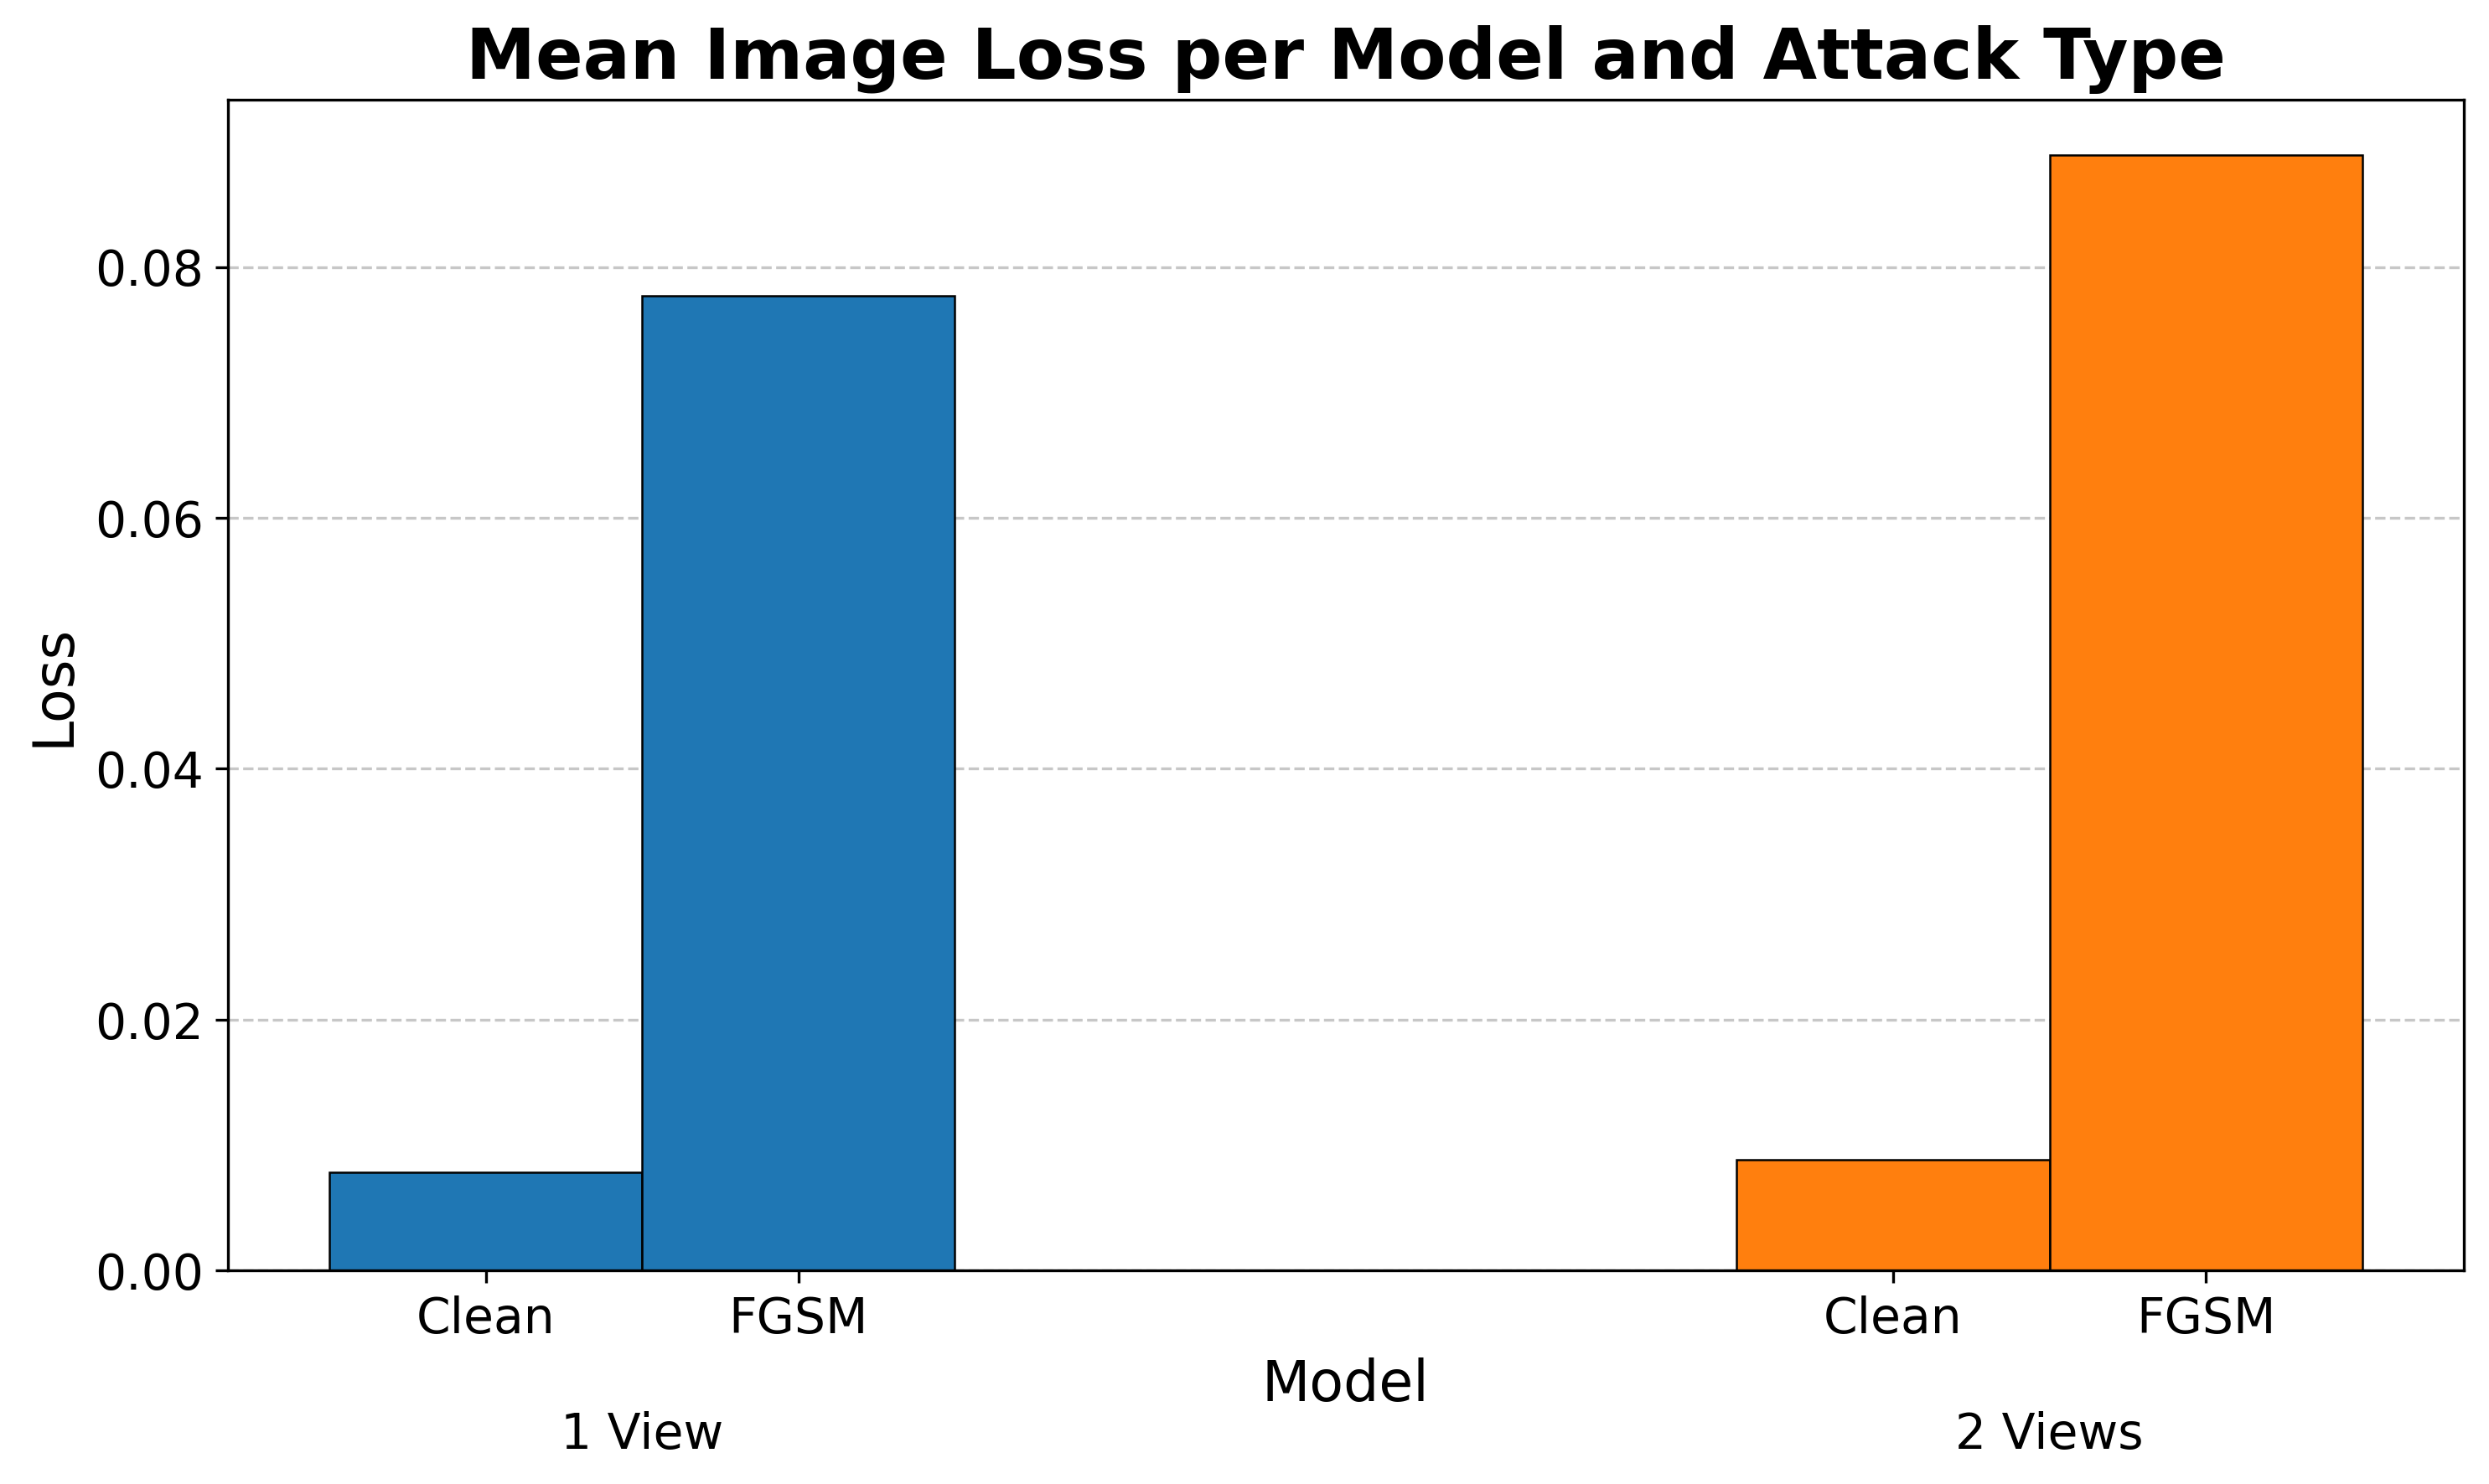

In [8]:
plot_model_attack_losses(mean_clean_loss)


/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_44552/1708859550.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


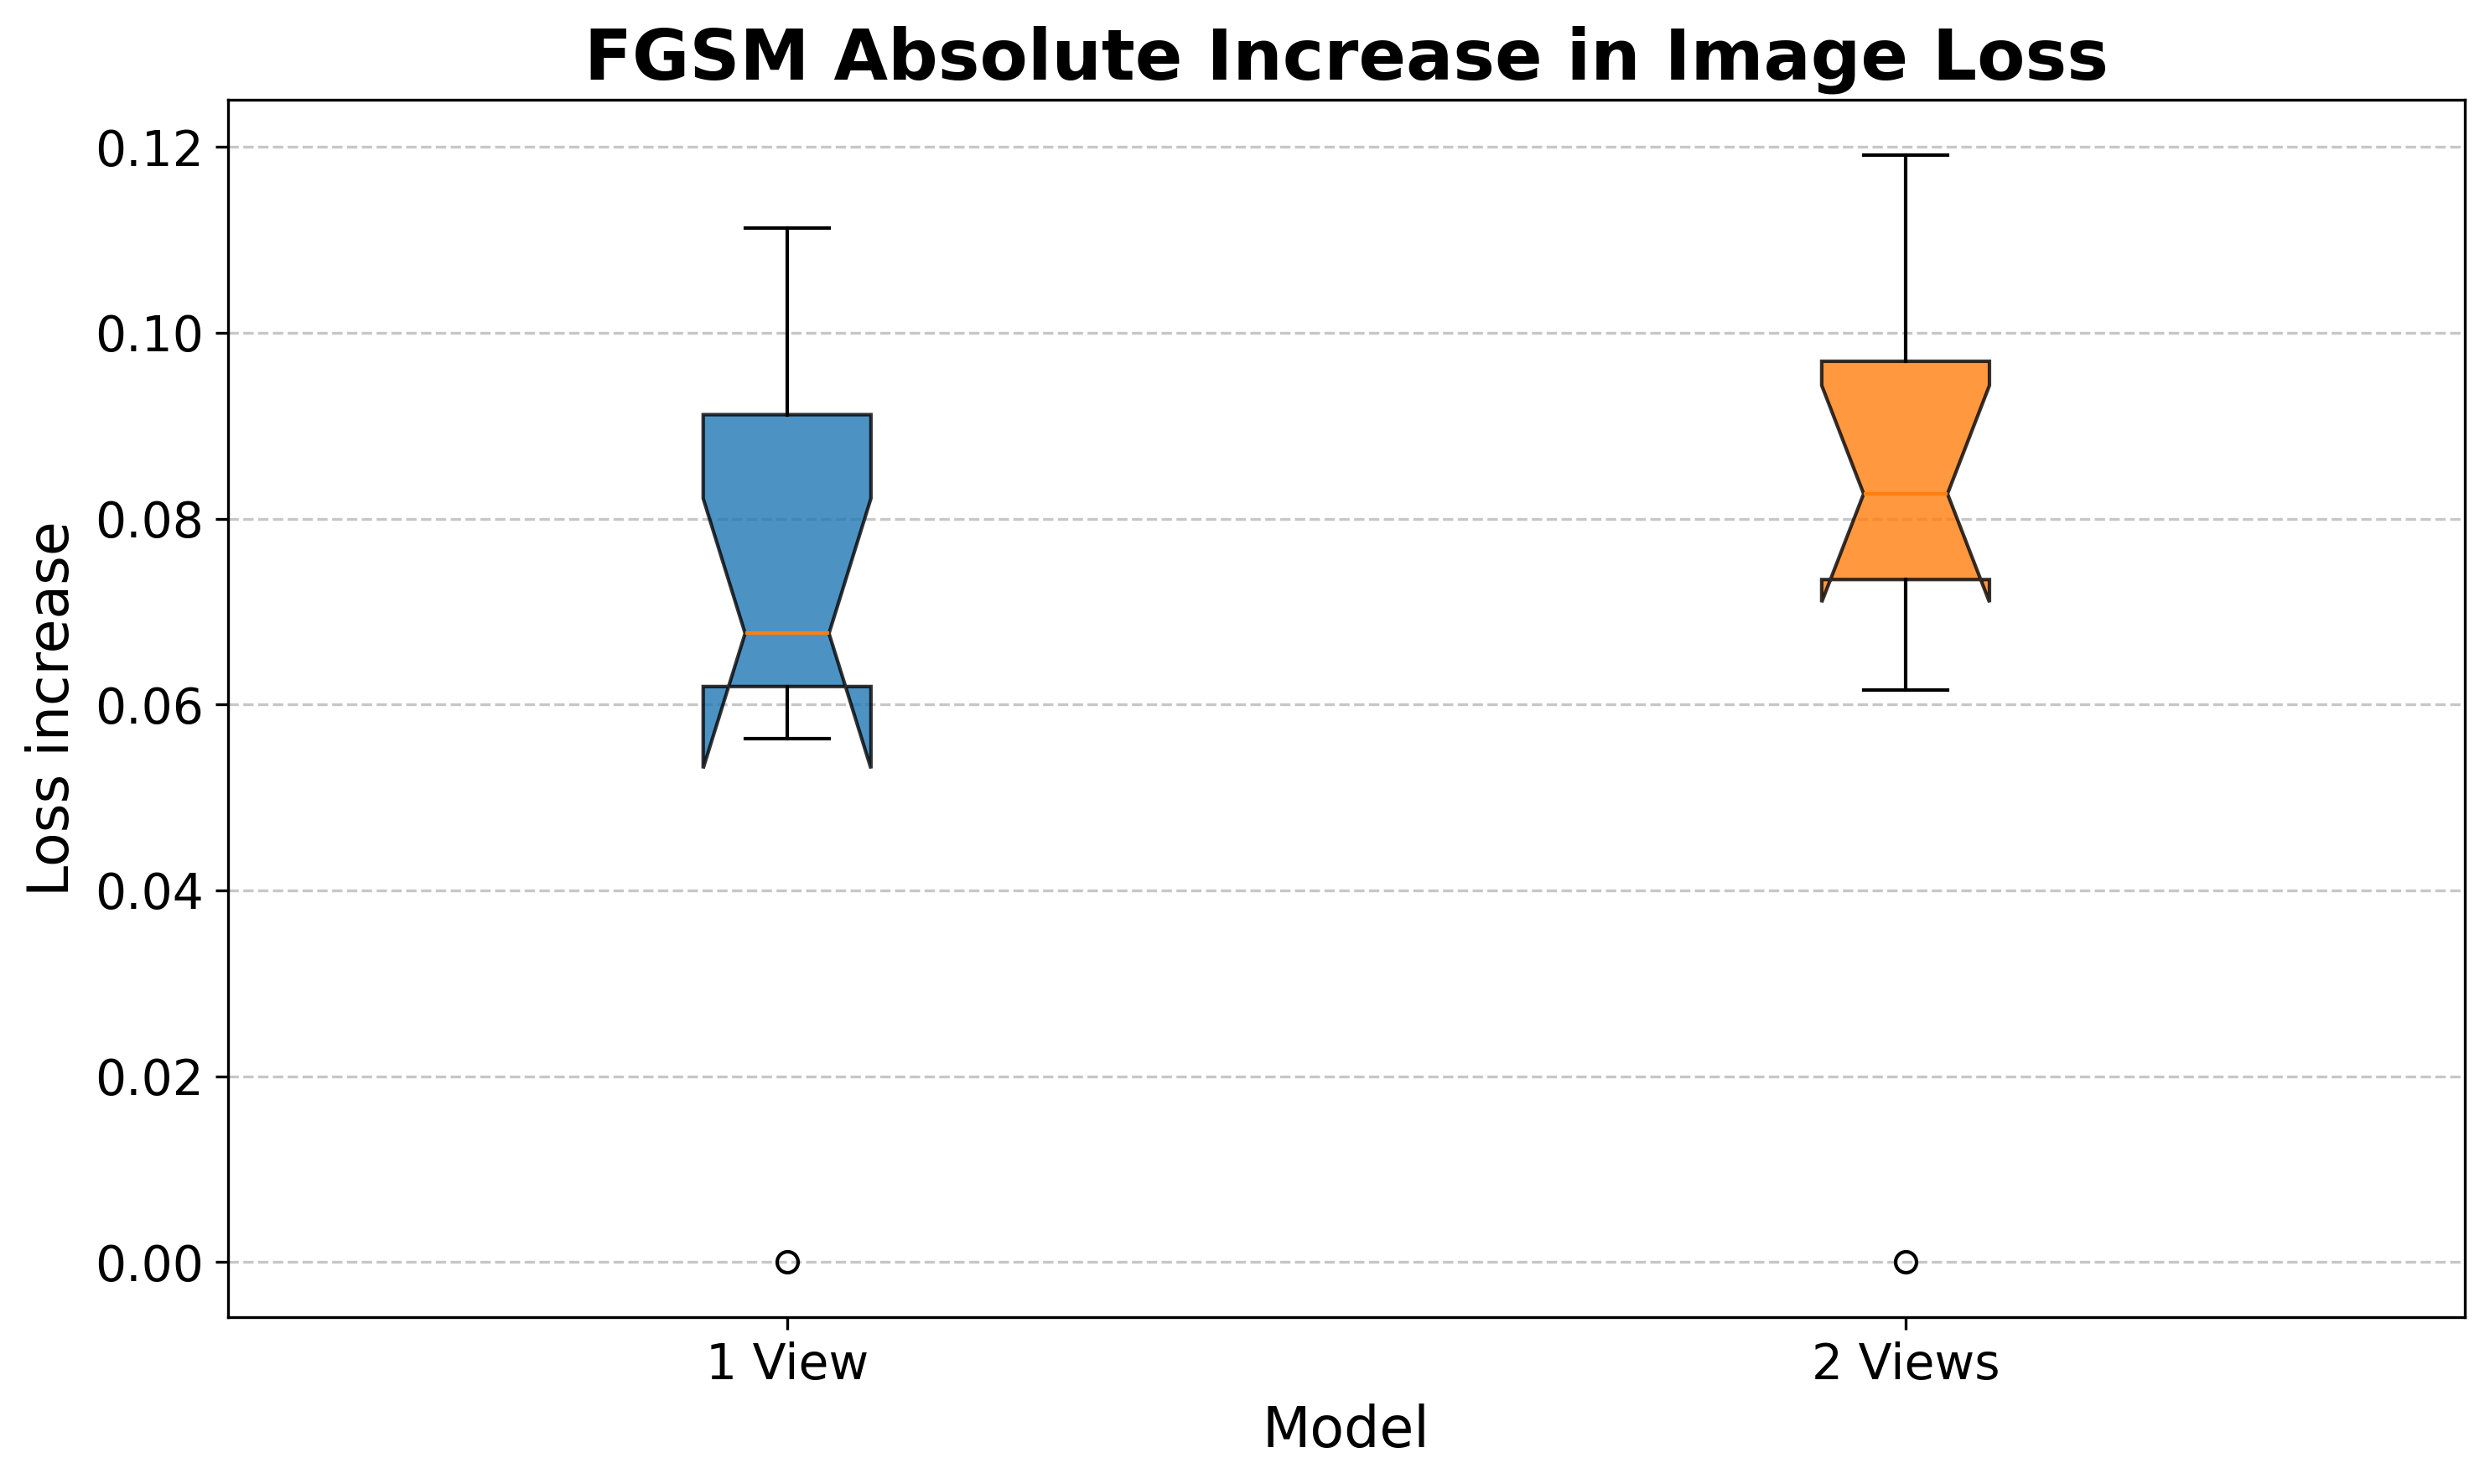

In [9]:
df = add_increase_columns(df)
plot_increase_boxplot(df, value_col='FGSM_IM_Abs_Increase')


### Label loss plot

The label loss is only available for the `2V` model in the provided CSV. The `1V` model has no label view, so these values are `NaN`.


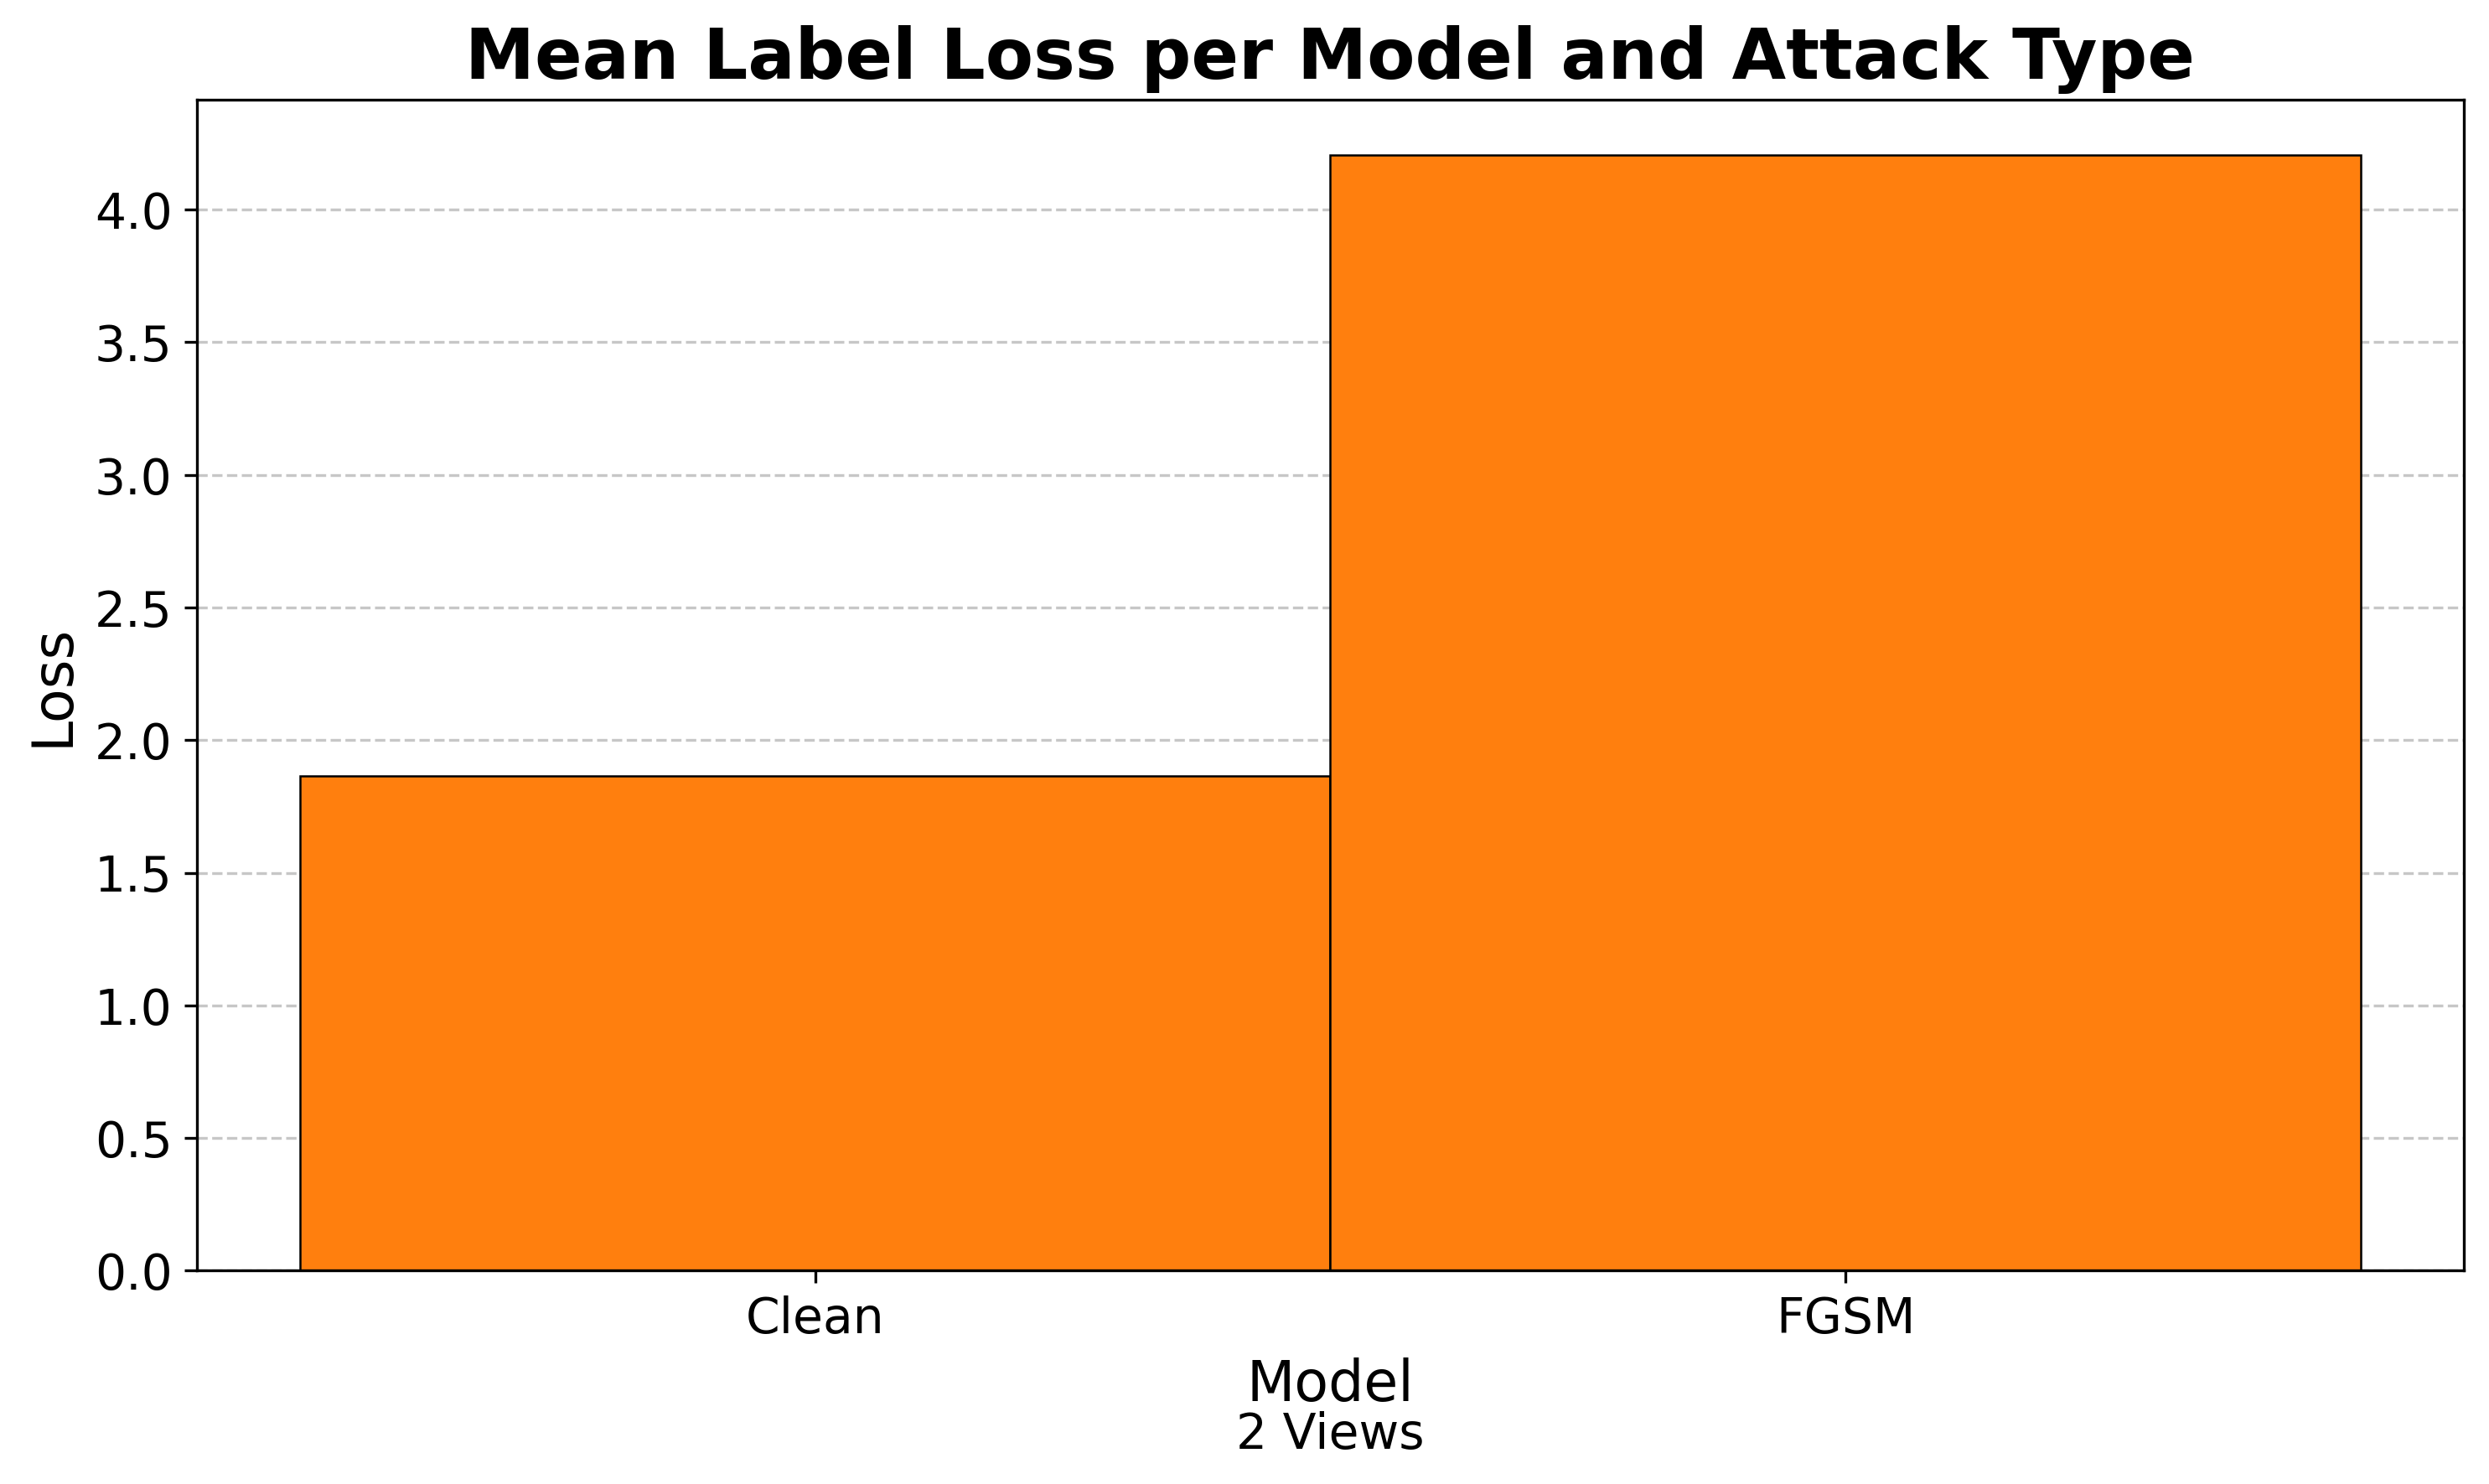

In [10]:
label_df = mean_losses(df.dropna(subset=['Clean_LA_Loss', 'FGSM_LA_Loss']), LABEL_LOSS_COL_MAP)
plot_model_attack_losses(
    label_df,
    loss_col_map=LABEL_LOSS_COL_MAP,
    model_order=label_df['model'].tolist(),
    title='Mean Label Loss per Model and Attack Type',
)


## Statistical tests


In [11]:
def select_models(data, models=MODEL_ORDER):
    return data.loc[data['model'].isin(models)].copy()


def kruskal_dunn_by_model(data, value_col, group_col='model', p_adjust='holm', show_plot=True):
    """Run Kruskal-Wallis followed by Dunn post-hoc test."""
    if sp is None:
        raise ModuleNotFoundError("Install scikit-posthocs to run Dunn post-hoc tests: pip install scikit-posthocs")

    data = data.dropna(subset=[value_col, group_col]).copy()
    model_order = [model for model in MODEL_ORDER if model in data[group_col].unique()]

    groups = [
        data.loc[data[group_col].eq(model), value_col].to_numpy()
        for model in model_order
    ]

    h_stat, p_value = kruskal(*groups)
    print(f'{value_col}')
    print(f'H-statistic: {h_stat:.6f}')
    print(f'P-value: {p_value:.6e}\n')

    dunn_results = sp.posthoc_dunn(
        data,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust,
    )

    dunn_results = dunn_results.loc[model_order, model_order]

    if show_plot:
        heatmap_args = {
            'linewidths': 0.25,
            'linecolor': '0.5',
            'clip_on': False,
            'square': True,
            'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3],
        }
        sp.sign_plot(dunn_results, **heatmap_args)
        plt.show()

    print(sp.compact_letter_display(dunn_results))
    return h_stat, p_value, dunn_results


In [12]:
df_stat_test = select_models(df)
print(df_stat_test.groupby('model').size())


model
1V    10
2V    10
dtype: int64


## Paired comparison: clean vs. FGSM

The rows in the CSV are paired per run. Therefore, the clean and FGSM losses can be compared within each model using a paired t-test.


In [14]:
def paired_clean_fgsm_comparison(data, model, clean_col='Clean_IM_Loss', fgsm_col='FGSM_IM_Loss'):
    model_df = data.loc[data['model'].eq(model), [clean_col, fgsm_col]].dropna()

    t_stat, p_value = stats.ttest_rel(model_df[fgsm_col], model_df[clean_col])
    print(f'{MODEL_LABEL_MAP.get(model, model)} — {fgsm_col} vs. {clean_col}')
    print(f'T-statistic: {t_stat:.6f}')
    print(f'P-value: {p_value:.6e}\n')
    return t_stat, p_value


for model in MODEL_ORDER:
    paired_clean_fgsm_comparison(df, model)


1 View — FGSM_IM_Loss vs. Clean_IM_Loss
T-statistic: 7.070288
P-value: 5.854190e-05

2 Views — FGSM_IM_Loss vs. Clean_IM_Loss
T-statistic: 7.625018
P-value: 3.241432e-05

